# From LangChain to Raw Embeddings: RAG from Scratch

You already built a document processor using LangChain. This notebook peels back every layer of that abstraction — chunking, embedding, similarity, retrieval — so you understand what's actually happening at each step.

**5 exercises.** Each one is 2–5 lines of code. The goal isn't to write a lot — it's to understand exactly what those lines are doing.

### What you'll build
| Step | LangChain wrapper | What's underneath |
|------|------------------|--------------------|
| Chunking | `RecursiveCharacterTextSplitter` | String splitting with overlap |
| Embedding | `OpenAIEmbeddings` / `HuggingFaceEmbeddings` | `SentenceTransformer.encode()` |
| Similarity | Handled by vector store | Cosine similarity (dot product / norms) |
| Retrieval | `VectorStore.similarity_search()` | Sort by score, return top-k |
| Generation | `RetrievalQA` chain | Prompt construction + LLM call |

### Prerequisites
```bash
pip install sentence-transformers numpy matplotlib scikit-learn scipy
```
> **Note:** On first run, `sentence-transformers` downloads the `all-MiniLM-L6-v2` model (~80MB). This takes ~30 seconds once, then it's cached locally.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine as scipy_cosine
from sentence_transformers import SentenceTransformer
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Sample document we'll use throughout ───────────────────────────────────────
SAMPLE_TEXT = """Gradient Descent

Gradient descent is an optimization algorithm used to minimize a loss function.
It works by iteratively moving in the direction of steepest descent — the negative gradient.
The gradient is a vector of partial derivatives pointing in the direction of greatest increase.
By moving opposite to the gradient, we converge toward a local minimum.

Learning Rate

The learning rate controls how large a step we take each iteration.
A learning rate that is too large causes the algorithm to overshoot the minimum and diverge.
A learning rate that is too small converges correctly but extremely slowly.
Choosing the right learning rate is one of the most impactful decisions when training a model.

Batch Gradient Descent

Batch gradient descent computes the gradient using the entire training dataset each step.
This gives an accurate gradient estimate but is slow and memory-intensive for large datasets.
You must load all training data into memory simultaneously, which can be prohibitive.

Stochastic Gradient Descent

Stochastic gradient descent (SGD) computes the gradient from one randomly chosen sample.
This is much faster per update but introduces noise into each gradient estimate.
The noisy updates can actually help the optimizer escape local minima.

Mini-batch Gradient Descent

Mini-batch gradient descent is the standard approach used in modern deep learning.
We compute the gradient from a small batch, typically 32 to 256 samples.
This balances the accuracy of batch GD with the computational speed of SGD.
Most deep learning frameworks default to mini-batch updates.

Momentum

Momentum is an extension to gradient descent that accumulates a velocity vector in time.
It helps accelerate learning in relevant directions and dampens oscillations.
The momentum hyperparameter beta controls how much of the previous velocity to retain.
A common value is beta = 0.9, meaning 90% of the previous direction is carried forward."""

print(f"Document: {len(SAMPLE_TEXT)} characters, ~{len(SAMPLE_TEXT.split())} words")

Document: 1948 characters, ~299 words


## The Big Picture

RAG has two phases:

- **Ingestion (offline):** You process your documents once, chunk them, embed each chunk into a vector, and store them in a vector database.
- **Retrieval (online):** When a question comes in, you embed the question the same way, find the most similar chunks, and inject them into the LLM prompt.

The key insight: **the embedding model is the bridge.** It maps both documents and queries into the same mathematical space, so "similar meaning" becomes "close in space."

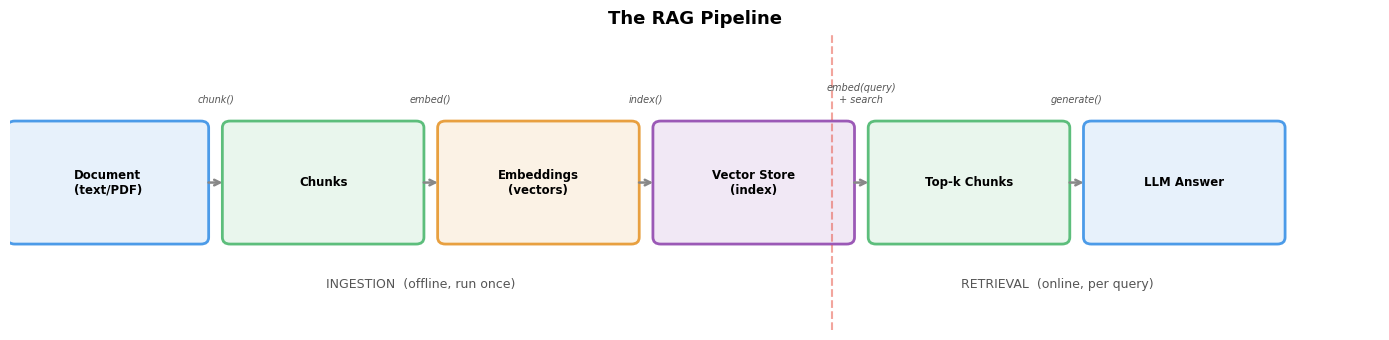

In [2]:
def draw_pipeline():
    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 3.5)
    ax.axis('off')

    boxes = [
        ("Document\n(text/PDF)",  1.0, "#4C9BE8"),
        ("Chunks",                3.2, "#5DBE7C"),
        ("Embeddings\n(vectors)", 5.4, "#E8A040"),
        ("Vector Store\n(index)", 7.6, "#9B59B6"),
        ("Top-k Chunks",          9.8, "#5DBE7C"),
        ("LLM Answer",           12.0, "#4C9BE8"),
    ]
    for label, x, color in boxes:
        rect = mpatches.FancyBboxPatch(
            (x - 0.95, 1.1), 1.9, 1.3,
            boxstyle="round,pad=0.08", lw=2,
            edgecolor=color, facecolor=color + "22")
        ax.add_patch(rect)
        ax.text(x, 1.75, label, ha='center', va='center', fontsize=8.5, fontweight='bold')

    steps = [
        (2.1, "chunk()"), (4.3, "embed()"), (6.5, "index()"),
        (8.7, "embed(query)\n+ search"), (10.9, "generate()")
    ]
    for x, label in steps:
        ax.annotate("", xy=(x + 0.1, 1.75), xytext=(x - 0.1, 1.75),
                    arrowprops=dict(arrowstyle="->", lw=1.8, color="#888"))
        ax.text(x, 2.7, label, ha='center', fontsize=7, color='#555', style='italic')

    ax.axvline(8.4, color='#e74c3c', lw=1.5, ls='--', alpha=0.5)
    ax.text(4.2, 0.5, "INGESTION  (offline, run once)",
            ha='center', fontsize=9, color='#555')
    ax.text(10.7, 0.5, "RETRIEVAL  (online, per query)",
            ha='center', fontsize=9, color='#555')
    ax.set_title("The RAG Pipeline", fontsize=13, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()

draw_pipeline()

---
## Part 1: Chunking

### Why do we chunk at all?

LLMs have context windows — a hard cap on how many tokens they can process at once. GPT-4 Turbo is 128k tokens; Claude Sonnet is 200k; smaller/local models can be 4k–8k. Even with large windows, stuffing the entire document into every prompt is expensive and noisy.

Chunking solves this: split the document into small pieces, retrieve only the relevant ones, and pass only those to the LLM. The trick is splitting *cleanly* — at sentence or paragraph boundaries, not mid-word.

### The naive approach (and its problem)

In [3]:
def naive_chunk(text: str, chunk_size: int) -> List[str]:
    """Split every chunk_size characters. Simple — but it cuts words in half."""
    return [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]

chunks = naive_chunk(SAMPLE_TEXT, chunk_size=200)
print(f"Produced {len(chunks)} chunks\n")
print("Chunk 1 boundary:")
print(repr(chunks[0][-30:]))  # Last 30 chars of chunk 1
print(repr(chunks[1][:30]))   # First 30 chars of chunk 2
print()
print("↑ See the problem? The split happens mid-word.")

Produced 10 chunks

Chunk 1 boundary:
'e negative gradient.\nThe gradi'
'ent is a vector of partial der'

↑ See the problem? The split happens mid-word.


### ✏️ Exercise 1: Fix the word-boundary bug

The naive chunker cuts words in half. Fix it so splits always happen at a space.

**The change:** Instead of always splitting at position `end`, find the last space *before* `end` using `text.rfind(' ', start, end)`. If there's no space (very long word), fall back to `end`.

**You only need to change one line.**

In [4]:
def word_boundary_chunk(text: str, chunk_size: int, overlap: int = 0) -> List[str]:
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        if end >= len(text):
            chunks.append(text[start:].strip())
            break

        # ✏️ YOUR TURN: find the last space before `end` so we don't cut mid-word.
        # Hint: text.rfind(' ', start, end) returns the index of the last space
        # in the slice text[start:end], or -1 if none found.
        split_point = text.rfind(' ', start, end) or end # ← change this line

        chunks.append(text[start:split_point].strip())
        start = split_point + 1 - overlap
    return [c for c in chunks if c]

# ── Test ─────────────────────────────────────────────────────────────────────
chunks = word_boundary_chunk(SAMPLE_TEXT, chunk_size=200, overlap=30)
print(f"Produced {len(chunks)} chunks")
print("\nChunk 1 end / Chunk 2 start:")
print(repr(chunks[0][-40:]))
print(repr(chunks[1][:40]))
assert all(not c[0].isalpha() or c[0] == c[0] for c in chunks), "Chunks should start cleanly"
assert chunks[0][-1] != ' ', "Should strip trailing spaces"
print("\n✅ Passed! Splits happen at word boundaries.")

Produced 12 chunks

Chunk 1 end / Chunk 2 start:
'est descent — the negative gradient.\nThe'
'— the negative gradient.\nThe gradient is'

✅ Passed! Splits happen at word boundaries.


<details>
<summary>💡 Solution (click to expand)</summary>

```python
# Replace the split_point line with:
last_space = text.rfind(' ', start, end)
split_point = last_space if last_space != -1 else end
```

Or as a one-liner: `split_point = text.rfind(' ', start, end) or end`

</details>

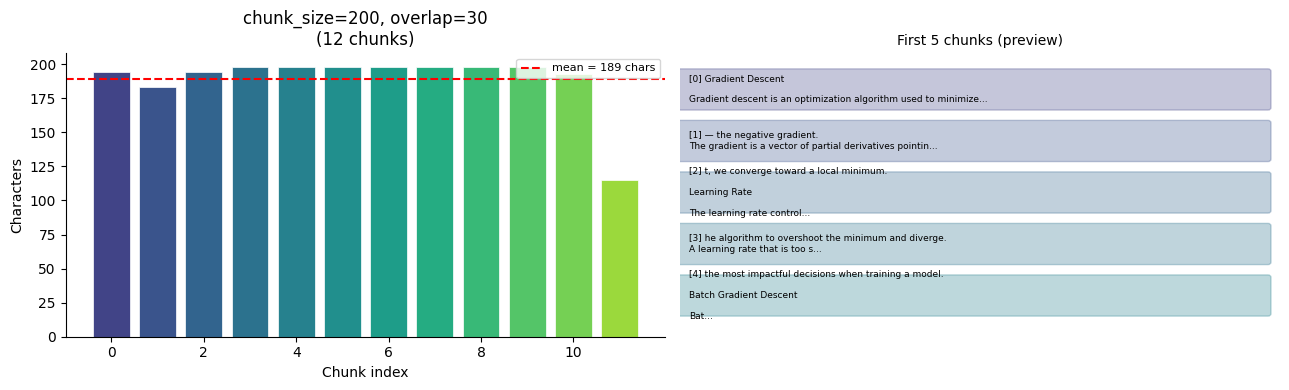

In [5]:
def visualize_chunks(text: str, chunks: List[str], title: str = "Chunks"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Left: chunk length distribution
    lengths = [len(c) for c in chunks]
    colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(chunks)))
    bars = ax1.bar(range(len(chunks)), lengths, color=colors, edgecolor='white', lw=0.5)
    ax1.axhline(np.mean(lengths), color='red', lw=1.5, ls='--', label=f'mean = {np.mean(lengths):.0f} chars')
    ax1.set_xlabel("Chunk index")
    ax1.set_ylabel("Characters")
    ax1.set_title(f"{title}\n({len(chunks)} chunks)")
    ax1.legend(fontsize=8)

    # Right: show first 3 chunks as colored text blocks
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, len(chunks[:5]) + 0.5)
    ax2.axis('off')
    ax2.set_title("First 5 chunks (preview)", fontsize=10)
    for i, chunk in enumerate(chunks[:5]):
        preview = chunk[:80] + ("..." if len(chunk) > 80 else "")
        y = len(chunks[:5]) - i - 0.2
        rect = mpatches.FancyBboxPatch((0, y - 0.35), 9.8, 0.7,
                                        boxstyle="round,pad=0.05", lw=1,
                                        facecolor=colors[i], alpha=0.3, edgecolor=colors[i])
        ax2.add_patch(rect)
        ax2.text(0.15, y, f"[{i}] {preview}", va='center', fontsize=6.5, wrap=True)

    plt.tight_layout()
    plt.show()

chunks_200 = word_boundary_chunk(SAMPLE_TEXT, chunk_size=200, overlap=30)
visualize_chunks(SAMPLE_TEXT, chunks_200, "chunk_size=200, overlap=30")

### What `RecursiveCharacterTextSplitter` actually does

LangChain's splitter is the same idea but smarter: it tries separators in order — `["\n\n", "\n", ".", " ", ""]` — and only falls back to the next one if a chunk is still too large. This preserves paragraph → sentence → word structure.

**The thing you got wrong in your plugin:** `chunk_size=500` is in *characters*, not tokens. For `all-MiniLM-L6-v2`, 500 characters ≈ 80–100 tokens. That's quite small — relevant context often spans 200–400 tokens. A better default is `chunk_size=1500` (roughly 250 tokens), with `overlap=150`.

---
## Part 2: Embeddings

An embedding is a fixed-length float vector that encodes the *meaning* of text. The model maps every possible sentence into a high-dimensional space (384 dimensions for `all-MiniLM-L6-v2`) such that sentences with similar meaning end up close together.

```
"The learning rate controls step size"   → [0.12, -0.45, 0.89, ...] (384 floats)
"How large is each gradient step?"       → [0.14, -0.43, 0.91, ...] (very similar!)
"Caramelization happens above 160°C"     → [-0.67, 0.22, -0.38, ...] (very different)
```

LangChain's `HuggingFaceEmbeddings` is a thin wrapper around `SentenceTransformer.encode()`. Let's use it directly.

In [10]:
# Corporate VPN / SSL-intercepting proxy fix:
# huggingface_hub uses httpx which has its own SSL stack — patch it before loading.
import httpx

_orig_client = httpx.Client.__init__
def _patched_client(self, *args, **kwargs):
    kwargs["verify"] = False
    _orig_client(self, *args, **kwargs)
httpx.Client.__init__ = _patched_client

_orig_async = httpx.AsyncClient.__init__
def _patched_async(self, *args, **kwargs):
    kwargs["verify"] = False
    _orig_async(self, *args, **kwargs)
httpx.AsyncClient.__init__ = _patched_async

# Downloads ~80MB on first run, cached after that
print("Loading sentence-transformers model...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

# A single embedding: 384 floats
single = model.encode("The learning rate controls gradient step size", convert_to_numpy=True)
print(f"Embedding shape: {single.shape}")
print(f"First 8 values: {single[:8].round(4)}")
print(f"L2 norm: {np.linalg.norm(single):.4f}") # ← normalized models produce unit vectors")

Loading sentence-transformers model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Embedding shape: (384,)
First 8 values: [-0.0405 -0.069   0.015   0.0115  0.0254  0.0141 -0.1054 -0.0346]
L2 norm: 1.0000


In [11]:
# Intuition: measure distance between semantically related vs. unrelated sentences
s1 = model.encode("Gradient descent minimizes a loss function", convert_to_numpy=True)
s2 = model.encode("We optimize by following the negative gradient", convert_to_numpy=True)
s3 = model.encode("Caramelization happens when sugar is heated", convert_to_numpy=True)

# Raw dot product as a quick similarity proxy (works for unit vectors)
print(f"Similar sentences:   dot={np.dot(s1, s2):.3f}")
print(f"Unrelated sentences: dot={np.dot(s1, s3):.3f}")
print()
print("Higher dot product → more similar meaning.")
print("For unit-norm vectors, dot product == cosine similarity (we'll build that next).")

Similar sentences:   dot=0.643
Unrelated sentences: dot=0.107

Higher dot product → more similar meaning.
For unit-norm vectors, dot product == cosine similarity (we'll build that next).


### ✏️ Exercise 2: Complete `embed_texts()`

This function should take a list of strings and return a 2D numpy array of shape `(n_texts, 384)`. You have the model, you know the method — fill in the body.

**Hint:** `model.encode()` accepts a list of strings and a `convert_to_numpy` flag.

In [13]:
def embed_texts(texts: List[str]) -> np.ndarray:
    """
    Embed a list of strings into a 2D numpy array.
    Returns shape: (len(texts), 384)
    """
    # ✏️ YOUR TURN: one line using model.encode()
    return model.encode(texts, convert_to_numpy=True)

# ── Test ─────────────────────────────────────────────────────────────────────
test_sentences = [
    "Gradient descent is an optimization algorithm.",
    "The learning rate controls step size.",
    "Mini-batch GD is the standard in deep learning.",
]
result = embed_texts(test_sentences)
assert result.shape == (3, 384), f"Expected (3, 384), got {result.shape}"
assert result.dtype == np.float32, f"Expected float32, got {result.dtype}"
print(f"✅ Shape: {result.shape} — each text → a 384-dim vector")

✅ Shape: (3, 384) — each text → a 384-dim vector


<details>
<summary>💡 Solution</summary>

```python
return model.encode(texts, convert_to_numpy=True)
```

That's it. The whole `HuggingFaceEmbeddings` LangChain class is essentially this one line plus some config boilerplate.

</details>

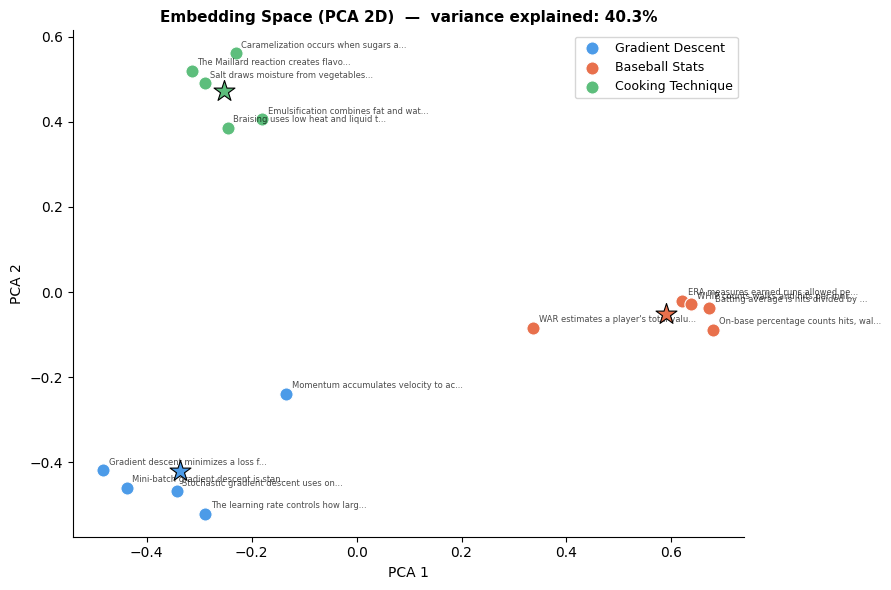


Same-topic sentences cluster together. Different topics are far apart.
This is why RAG works: 'what is learning rate?' lands near the gradient descent cluster.


In [14]:
# Visualize embedding clusters with PCA (384D → 2D)
# Using three clearly different topic groups
TOPIC_SENTENCES = {
    "Gradient Descent": [
        "Gradient descent minimizes a loss function by following the negative gradient.",
        "The learning rate controls how large each optimization step is.",
        "Stochastic gradient descent uses one sample per update.",
        "Mini-batch gradient descent is standard in deep learning.",
        "Momentum accumulates velocity to accelerate training.",
    ],
    "Baseball Stats": [
        "ERA measures earned runs allowed per nine innings pitched.",
        "On-base percentage counts hits, walks, and hit-by-pitches.",
        "WAR estimates a player's total value in wins above average.",
        "Batting average is hits divided by at-bats.",
        "WHIP counts walks and hits per inning pitched.",
    ],
    "Cooking Technique": [
        "Caramelization occurs when sugars are heated above 160 degrees Celsius.",
        "The Maillard reaction creates flavor compounds when proteins brown.",
        "Braising uses low heat and liquid to tenderize tough meat cuts.",
        "Emulsification combines fat and water using an emulsifier like egg yolk.",
        "Salt draws moisture from vegetables through osmosis.",
    ],
}

all_sentences = [s for sentences in TOPIC_SENTENCES.values() for s in sentences]
all_labels = [topic for topic, sentences in TOPIC_SENTENCES.items() for _ in sentences]
all_embeddings = embed_texts(all_sentences)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(all_embeddings)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {'Gradient Descent': '#4C9BE8', 'Baseball Stats': '#E8704C', 'Cooking Technique': '#5DBE7C'}
for topic, color in colors.items():
    mask = [l == topic for l in all_labels]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    ax.scatter(xs, ys, c=color, s=90, label=topic, zorder=3, edgecolors='white', lw=0.8)
    cx, cy = xs.mean(), ys.mean()
    ax.scatter(cx, cy, c=color, s=250, marker='*', zorder=4, edgecolors='black', lw=0.8)

for i, (sentence, label) in enumerate(zip(all_sentences, all_labels)):
    short = sentence[:35] + "..."
    ax.annotate(short, (coords[i, 0], coords[i, 1]),
                fontsize=6, alpha=0.7, xytext=(4, 4), textcoords='offset points')

ax.set_title(
    f"Embedding Space (PCA 2D)  —  variance explained: {pca.explained_variance_ratio_.sum():.1%}",
    fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
plt.tight_layout()
plt.show()

print()
print("Same-topic sentences cluster together. Different topics are far apart.")
print("This is why RAG works: 'what is learning rate?' lands near the gradient descent cluster.")

---
## Part 3: Cosine Similarity

Now we know how to turn text into vectors. How do we measure if two vectors are "close"?

We use **cosine similarity** — the cosine of the angle between two vectors:

$$\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

- Result is always in `[-1, 1]`: `1.0` = identical direction, `0` = perpendicular (unrelated), `-1` = opposite
- We use cosine (angle) rather than Euclidean distance (straight-line length) because we care about *direction*, not magnitude — a long detailed sentence and a short summary of the same concept should be close
- For unit-norm models (like `all-MiniLM-L6-v2`), the denominator is always 1, so cosine similarity reduces to a plain dot product

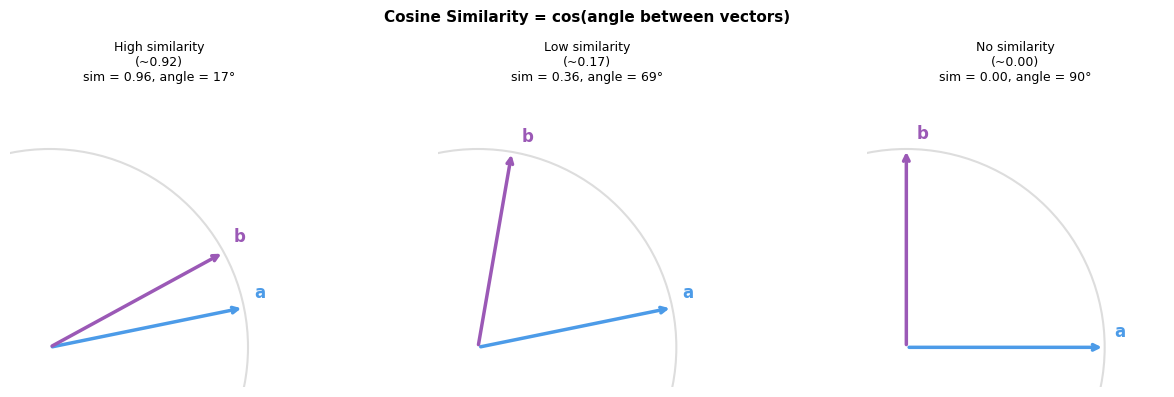

In [15]:
# Visual: cosine similarity as angle between 2D vectors
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
examples = [
    ("High similarity\n(~0.92)",  [0.98, 0.20], [0.88, 0.48], '#5DBE7C'),
    ("Low similarity\n(~0.17)",   [0.98, 0.20], [0.17, 0.98], '#E8A040'),
    ("No similarity\n(~0.00)",    [1.0,  0.0],  [0.0,  1.0],  '#E8704C'),
]
for ax, (title, a, b, color) in zip(axes, examples):
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    a /= np.linalg.norm(a); b /= np.linalg.norm(b)
    sim = np.dot(a, b)
    ax.set_xlim(-0.2, 1.3); ax.set_ylim(-0.2, 1.3)
    circle = plt.Circle((0, 0), 1.0, fill=False, color='#ddd', lw=1.5)
    ax.add_patch(circle)
    ax.annotate("", xy=a, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", lw=2.5, color='#4C9BE8'))
    ax.annotate("", xy=b, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", lw=2.5, color='#9B59B6'))
    ax.text(a[0]+0.05, a[1]+0.05, 'a', color='#4C9BE8', fontsize=12, fontweight='bold')
    ax.text(b[0]+0.05, b[1]+0.05, 'b', color='#9B59B6', fontsize=12, fontweight='bold')
    angle = np.degrees(np.arccos(np.clip(sim, -1, 1)))
    ax.set_title(f"{title}\nsim = {sim:.2f}, angle = {angle:.0f}°", fontsize=9)
    ax.set_aspect('equal'); ax.axis('off')

fig.suptitle("Cosine Similarity = cos(angle between vectors)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### ✏️ Exercise 3: Implement `cosine_similarity()` from scratch

Translate the formula into numpy. You need two operations:
- `np.dot(a, b)` — dot product (numerator)
- `np.linalg.norm(v)` — L2 norm / magnitude (denominator)

**This is 1 line.**

In [17]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """
    Cosine similarity between two 1D vectors.
    Formula: (a · b) / (||a|| * ||b||)
    Returns a float in [-1, 1].
    """
    # ✏️ YOUR TURN: implement the formula using np.dot() and np.linalg.norm()
    return (np.dot(a,b))

# ── Test against scipy's reference implementation ─────────────────────────────
v1 = model.encode("Gradient descent minimizes a loss function", convert_to_numpy=True)
v2 = model.encode("We optimize by following the negative gradient", convert_to_numpy=True)
v3 = model.encode("Caramelization happens when sugar is heated", convert_to_numpy=True)

yours_12 = cosine_similarity(v1, v2)
reference_12 = 1 - scipy_cosine(v1, v2)  # scipy uses cosine DISTANCE; 1 - dist = similarity

assert abs(yours_12 - reference_12) < 1e-5, f"Got {yours_12:.4f}, expected {reference_12:.4f}"
print(f"Similar pair:   {yours_12:.4f}  (expected ≈ {reference_12:.4f})")
print(f"Different pair: {cosine_similarity(v1, v3):.4f}")
print("✅ Matches scipy reference!")

Similar pair:   0.6426  (expected ≈ 0.6426)
Different pair: 0.1073
✅ Matches scipy reference!


<details>
<summary>💡 Solution</summary>

```python
return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
```

For `all-MiniLM-L6-v2`, vectors are unit-normalized, so `np.linalg.norm(a) ≈ 1.0` and the division changes nothing. But it's important to include it — not all models normalize outputs, and without the denominator you're computing dot product, not cosine similarity.

</details>

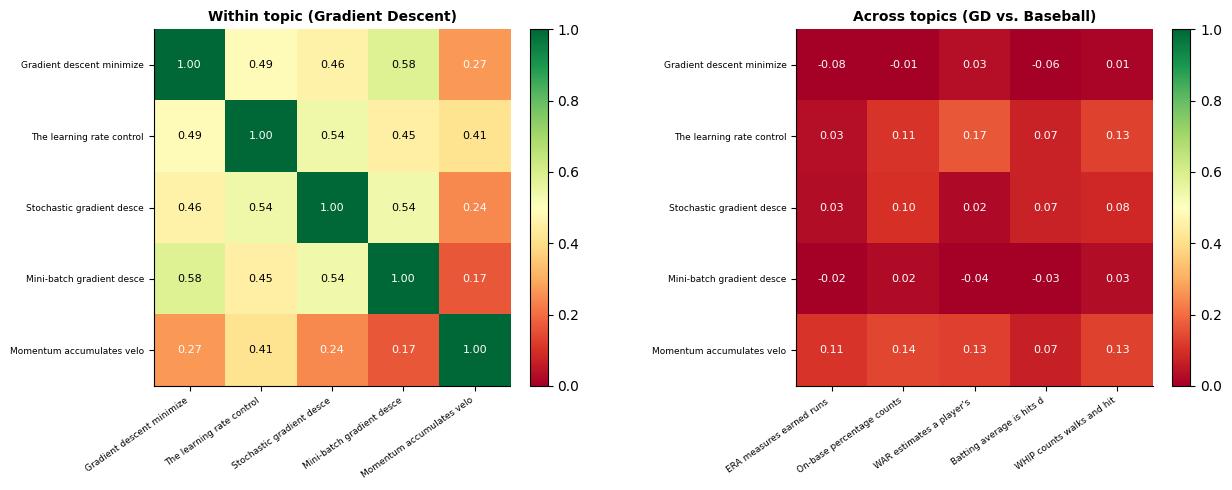

Same-topic pairs: high similarity (green). Cross-topic pairs: low similarity (red).
This is exactly what the vector store exploits during retrieval.


In [18]:
# Similarity heatmap: gradient descent sentences vs. baseball sentences
gd_sentences = TOPIC_SENTENCES["Gradient Descent"]
bb_sentences = TOPIC_SENTENCES["Baseball Stats"]

gd_embs = embed_texts(gd_sentences)
bb_embs = embed_texts(bb_sentences)

# Build a (5x5) within-topic and (5x5) cross-topic similarity matrix
within = np.array([[cosine_similarity(gd_embs[i], gd_embs[j])
                    for j in range(5)] for i in range(5)])
across = np.array([[cosine_similarity(gd_embs[i], bb_embs[j])
                    for j in range(5)] for i in range(5)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, matrix, title, xlabels, ylabels in [
    (ax1, within, "Within topic (Gradient Descent)",
     [s[:25] for s in gd_sentences], [s[:25] for s in gd_sentences]),
    (ax2, across, "Across topics (GD vs. Baseball)",
     [s[:25] for s in bb_sentences], [s[:25] for s in gd_sentences]),
]:
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(5)); ax.set_xticklabels(xlabels, rotation=35, ha='right', fontsize=6.5)
    ax.set_yticks(range(5)); ax.set_yticklabels(ylabels, fontsize=6.5)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha='center', va='center',
                    fontsize=8, color='black' if 0.3 < matrix[i, j] < 0.85 else 'white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
print("Same-topic pairs: high similarity (green). Cross-topic pairs: low similarity (red).")
print("This is exactly what the vector store exploits during retrieval.")

---
## Part 4: Vector Store from Scratch

ChromeDB, Pinecone, pgvector — they all do the same thing underneath:

1. **Index:** store `(text, embedding)` pairs
2. **Search:** given a query embedding, compute similarity to every stored embedding, return top-k

For small datasets (< 100k chunks), a flat numpy search is totally fine — no approximate nearest neighbor index needed. At scale you'd use FAISS or HNSW graphs to avoid comparing the query against every stored vector.

Here's the full class with `index()` implemented. You need to complete `retrieve()`.

In [22]:
class MinimalVectorStore:
    """
    A tiny vector store backed by a numpy array.
    Functionally equivalent to ChromaDB for small collections.
    """

    def __init__(self):
        self.texts: List[str] = []
        self.embeddings: np.ndarray = np.array([])

    def index(self, texts: List[str]) -> None:
        """Embed and store a list of text chunks."""
        self.texts = texts
        self.embeddings = embed_texts(texts)
        print(f"Indexed {len(texts)} chunks — embedding matrix: {self.embeddings.shape}")

    def retrieve(self, query: str, k: int = 3) -> List[Tuple[str, float]]:
        """
        Find the k most similar chunks to the query.

        Returns: list of (chunk_text, similarity_score), highest score first.
        """
        # ✏️ YOUR TURN (Exercise 4):
        # Step 1: embed the query string into a single vector
        # Step 2: compute cosine_similarity() between the query vector and each stored embedding
        # Step 3: zip texts and scores, sort descending by score, return top k
        query_vec = embed_texts([query])[0]
        scores = [cosine_similarity(query_vec, emb) for emb in self.embeddings]
        ranked = sorted(zip(self.texts, scores), key=lambda x: x[1], reverse=True)
        return ranked[:k]

### ✏️ Exercise 4: Complete `retrieve()`

You have all the pieces:
- `embed_texts([query])[0]` — embed one string into a vector (or `model.encode(query, ...)`)
- `cosine_similarity(query_vec, self.embeddings[i])` — score one stored chunk
- `sorted(..., key=lambda x: x[1], reverse=True)[:k]` — get top-k

**~4 lines.**

In [23]:
# ── Test your implementation ──────────────────────────────────────────────────
chunks = word_boundary_chunk(SAMPLE_TEXT, chunk_size=300, overlap=50)
store = MinimalVectorStore()
store.index(chunks)

query = "What is the difference between batch and stochastic gradient descent?"
results = store.retrieve(query, k=3)

print(f"Query: '{query}'\n")
print("Top 3 retrieved chunks:\n")
for i, (chunk, score) in enumerate(results):
    print(f"[{i+1}] score={score:.3f}")
    print(f"    {chunk[:120]}...\n")

assert len(results) == 3, "Should return exactly k=3 results"
assert results[0][1] >= results[1][1] >= results[2][1], "Should be sorted highest-first"
assert all(0 <= score <= 1 for _, score in results), "Scores should be in [0, 1]"
print("✅ Passed!")

Indexed 8 chunks — embedding matrix: (8, 384)
Query: 'What is the difference between batch and stochastic gradient descent?'

Top 3 retrieved chunks:

[1] score=0.619
    to overshoot the minimum and diverge.
A learning rate that is too small converges correctly but extremely slowly.
Choosi...

[2] score=0.605
    ibitive.

Stochastic Gradient Descent

Stochastic gradient descent (SGD) computes the gradient from one randomly chosen ...

[3] score=0.574
    uracy of batch GD with the computational speed of SGD.
Most deep learning frameworks default to mini-batch updates.

Mom...

✅ Passed!


<details>
<summary>💡 Solution</summary>

```python
def retrieve(self, query: str, k: int = 3) -> List[Tuple[str, float]]:
    query_vec = embed_texts([query])[0]
    scores = [cosine_similarity(query_vec, emb) for emb in self.embeddings]
    ranked = sorted(zip(self.texts, scores), key=lambda x: x[1], reverse=True)
    return ranked[:k]
```

**What ChromaDB adds on top of this:** approximate nearest-neighbor search (so you don't compare against every vector when you have millions), persistence to disk, metadata filtering, and a client/server architecture. For < 100k documents, the numpy version above is fast enough.

</details>

---
## Part 5: The Full Pipeline Assembled

Now let's wire everything together into a `RawRAG` class — no LangChain anywhere.

In [24]:
class RawRAG:
    """
    Minimal RAG pipeline with no external framework dependencies.

    Ingestion:  text → chunks → embeddings → vector store
    Retrieval:  query → embedding → top-k chunks → prompt
    """

    def __init__(self, chunk_size: int = 400, chunk_overlap: int = 50, top_k: int = 3):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.top_k = top_k
        self.store = MinimalVectorStore()

    def ingest(self, text: str) -> None:
        chunks = word_boundary_chunk(text, self.chunk_size, self.chunk_overlap)
        self.store.index(chunks)
        print(f"Ingested {len(chunks)} chunks (size={self.chunk_size}, overlap={self.chunk_overlap})")

    def retrieve(self, query: str) -> List[Tuple[str, float]]:
        return self.store.retrieve(query, k=self.top_k)

    def build_prompt(self, query: str) -> str:
        """Construct the prompt you'd send to an LLM."""
        results = self.retrieve(query)
        context = "\n\n---\n\n".join(
            f"[Chunk {i+1}, score={score:.3f}]\n{chunk}"
            for i, (chunk, score) in enumerate(results)
        )
        return (
            f"Use the following context to answer the question.\n\n"
            f"{context}\n\n"
            f"Question: {query}\n"
            f"Answer:"
        )


# ── Run it ────────────────────────────────────────────────────────────────────
rag = RawRAG(chunk_size=400, chunk_overlap=50, top_k=3)
rag.ingest(SAMPLE_TEXT)

queries = [
    "What is the difference between batch and stochastic gradient descent?",
    "How does momentum help during training?",
    "Why is choosing the learning rate important?",
]

for q in queries:
    results = rag.retrieve(q)
    print(f"\nQ: {q}")
    print(f"   Best match (score={results[0][1]:.3f}): {results[0][0][:100]}...")

Indexed 6 chunks — embedding matrix: (6, 384)
Ingested 6 chunks (size=400, overlap=50)

Q: What is the difference between batch and stochastic gradient descent?
   Best match (score=0.712): training a model.

Batch Gradient Descent

Batch gradient descent computes the gradient using the en...

Q: How does momentum help during training?
   Best match (score=0.412): ning.
We compute the gradient from a small batch, typically 32 to 256 samples.
This balances the acc...

Q: Why is choosing the learning rate important?
   Best match (score=0.504): local minimum.

Learning Rate

The learning rate controls how large a step we take each iteration.
A...


In [25]:
# Show the actual prompt that would go to an LLM
query = "What is mini-batch gradient descent and why is it the standard approach?"
print(rag.build_prompt(query))
print("\n" + "─" * 60)
print("↑ This is what you'd send to Claude / GPT / Gemini.")
print("  The LLM only sees these retrieved chunks — not the full document.")
print("  If the retrieval is bad, the answer will be bad (GIGO).")

Use the following context to answer the question.

[Chunk 1, score=0.647]
training a model.

Batch Gradient Descent

Batch gradient descent computes the gradient using the entire training dataset each step.
This gives an accurate gradient estimate but is slow and memory-intensive for large datasets.
You must load all training data into memory simultaneously, which can be prohibitive.

Stochastic Gradient Descent

Stochastic gradient descent (SGD) computes the gradient

---

[Chunk 2, score=0.636]
local minimum.

Learning Rate

The learning rate controls how large a step we take each iteration.
A learning rate that is too large causes the algorithm to overshoot the minimum and diverge.
A learning rate that is too small converges correctly but extremely slowly.
Choosing the right learning rate is one of the most impactful decisions when training a model.

Batch Gradient Descent

Batch

---

[Chunk 3, score=0.635]
stic gradient descent (SGD) computes the gradient from one randomly chosen 

---
## Part 6: Chunk Size Experiment

Chunk size is one of the highest-leverage hyperparameters in RAG. Too small: individual chunks lose context and the model can't form a coherent answer. Too large: retrieval is imprecise — you pull in a lot of irrelevant text alongside the relevant part.

Let's measure retrieval quality quantitatively. For each chunk size, we'll check whether the best retrieved chunk actually contains the answer keyword.

### ✏️ Exercise 5: Run the experiment with more chunk sizes

The function is written. Your job: run it with a wider range of chunk sizes and observe the pattern.

In [ ]:
def retrieval_quality_experiment(chunk_sizes: List[int]) -> dict:
    """
    For each chunk size, build a RAG pipeline and test it on
    several query/keyword pairs. Returns hit-rate per chunk size.
    """
    EVAL_PAIRS = [
        ("What is stochastic gradient descent?",    "stochastic"),
        ("How does momentum work?",                 "momentum"),
        ("What controls the step size?",            "learning rate"),
        ("What is mini-batch gradient descent?",    "mini-batch"),
        ("How does batch GD differ from SGD?",      "batch"),
    ]

    results = {}
    for size in chunk_sizes:
        rag = RawRAG(chunk_size=size, chunk_overlap=size // 5, top_k=2)
        rag.ingest(SAMPLE_TEXT)
        hits = 0
        for query, keyword in EVAL_PAIRS:
            top_chunks = rag.retrieve(query)
            if any(keyword.lower() in chunk.lower() for chunk, _ in top_chunks):
                hits += 1
        hit_rate = hits / len(EVAL_PAIRS)
        results[size] = hit_rate
        print(f"  chunk_size={size:4d}  hit_rate={hit_rate:.0%}  ({hits}/{len(EVAL_PAIRS)} queries)")
    return results

print("Running retrieval quality experiment...\n")

# ✏️ YOUR TURN: Add more chunk sizes to this list.
# Try values from 50 all the way to 2000. What pattern do you see?
chunk_sizes = [25, 50, 75, 100, 300, 500, 1000, 1500, 2000]  # ← extend this list

results = retrieval_quality_experiment(chunk_sizes)

Running retrieval quality experiment...



In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
sizes = list(results.keys())
hit_rates = [results[s] for s in sizes]

ax.plot(sizes, hit_rates, 'o-', color='#4C9BE8', lw=2.5, markersize=8, markerfacecolor='white',
        markeredgewidth=2.5)
ax.fill_between(sizes, hit_rates, alpha=0.12, color='#4C9BE8')
ax.set_ylim(0, 1.1)
ax.set_xlabel("chunk_size (characters)", fontsize=11)
ax.set_ylabel("Hit rate", fontsize=11)
ax.set_title("Retrieval Quality vs. Chunk Size", fontsize=13, fontweight='bold')
ax.axhline(1.0, color='#5DBE7C', lw=1.5, ls='--', alpha=0.7, label='perfect retrieval')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=9)
for x, y in zip(sizes, hit_rates):
    ax.annotate(f"{y:.0%}", (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print()
print("What to look for:")
print("  • Very small chunks (< 100 chars): low hit rate — sentences are incomplete")
print("  • Medium chunks (200–600 chars):   usually best — full sentences + context")
print("  • Very large chunks (> 1000 chars): lower precision — noise drowns out signal")
print("  • Your document matters: short documents with dense info need smaller chunks")

---
## What's Next

You've now built the full RAG pipeline from scratch. Here's what the next layers of complexity look like:

### Re-ranking
Retrieval finds candidates fast. Re-ranking re-scores them with a slower, more accurate cross-encoder model. The pattern: retrieve top-20, re-rank to top-3. `sentence-transformers` includes cross-encoder models for this.

### Hybrid Search
Dense retrieval (embeddings) is great for semantic similarity. Sparse retrieval (BM25, TF-IDF keyword matching) is better for exact terms. Production systems combine both — called hybrid search. LangChain's `EnsembleRetriever` does this.

### Multimodal Embeddings (what LLaVA is NOT)
Your `ImageProcessor` converts images to text via LLaVA, then embeds the text. That's fine for document images. Native multimodal retrieval (CLIP, BLIP-2) instead embeds images and text into the **same vector space** — a query like "baseball stadium at night" can directly retrieve matching images without describing them in text first.

### What your plugin is missing
Your `workspace_memory` plugin has ingestion (file → chunks) but not retrieval. The next piece is a `WorkspaceMemorySkill` that:
1. Maintains a persistent `MinimalVectorStore` (or ChromaDB) across sessions
2. Exposes a `search(query)` tool that the agent can call
3. Injects retrieved chunks into the system prompt before each response

That's the full RAG loop — and it's only about 50 lines on top of what you've already built.

---
*Built for [ML Edge](https://mle-edge.dev) — self-directed ML curriculum*